In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, auc, RocCurveDisplay,roc_curve

In [137]:
# !wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

In [138]:
df = pd.read_csv('course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   object 
 1   industry                  1328 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   object 
 5   location                  1399 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.9+ KB


In [177]:
categorical = list(df.dtypes[df.dtypes == 'object'].index)
categorical

['lead_source', 'industry', 'employment_status', 'location']

In [175]:
df[categorical]

,lead_source,industry,employment_status,location
0,paid_ads,NA,unemployed,south_america
1,social_media,retail,employed,south_america
2,events,healthcare,unemployed,australia
3,paid_ads,retail,NA,australia
4,referral,education,self_employed,europe
...,...,...,...,...
1457,referral,manufacturing,self_employed,north_america
1458,referral,technology,student,europe
1459,paid_ads,technology,student,north_america
1460,referral,NA,self_employed,north_america


In [179]:
numerical = list(df.dtypes[df.dtypes != 'object'].index)
df[numerical]

,number_of_courses_viewed,annual_income,interaction_count,lead_score,converted
0,1,79450.0,4,0.94,1
1,1,46992.0,1,0.80,0
2,5,78796.0,3,0.69,1
3,2,83843.0,1,0.87,0
4,3,85012.0,3,0.62,1
...,...,...,...,...,...
1457,1,0.0,4,0.53,1
1458,3,65259.0,2,0.24,1
1459,1,45688.0,3,0.02,1
1460,5,71016.0,0,0.25,1


In [140]:
# lead_source categorical
df.lead_source.value_counts()

lead_source
organic_search    282
social_media      278
paid_ads          264
referral          260
events            250
Name: count, dtype: int64

In [141]:
df.lead_source.isna().sum()

np.int64(128)

In [142]:
df.industry.value_counts()
# industry categorical

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
Name: count, dtype: int64

In [143]:
df.industry.isna().sum()

np.int64(134)

In [144]:
df.number_of_courses_viewed.nunique()

10

In [145]:
df.employment_status.unique()

array(['unemployed', 'employed', nan, 'self_employed', 'student'],
      dtype=object)

In [146]:
es = df.employment_status.value_counts()
# employment_status categorical
es

employment_status
self_employed    352
student          348
unemployed       334
employed         328
Name: count, dtype: int64

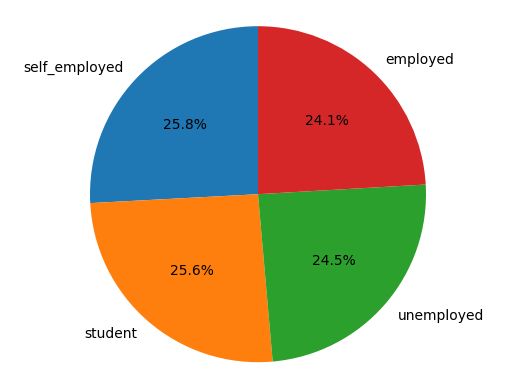

In [147]:
plt.pie(es, labels=es.index, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.show()


In [148]:
## location
df.location.value_counts()
# location categorical

location
north_america    225
europe           216
middle_east      198
asia             195
south_america    192
africa           188
australia        185
Name: count, dtype: int64

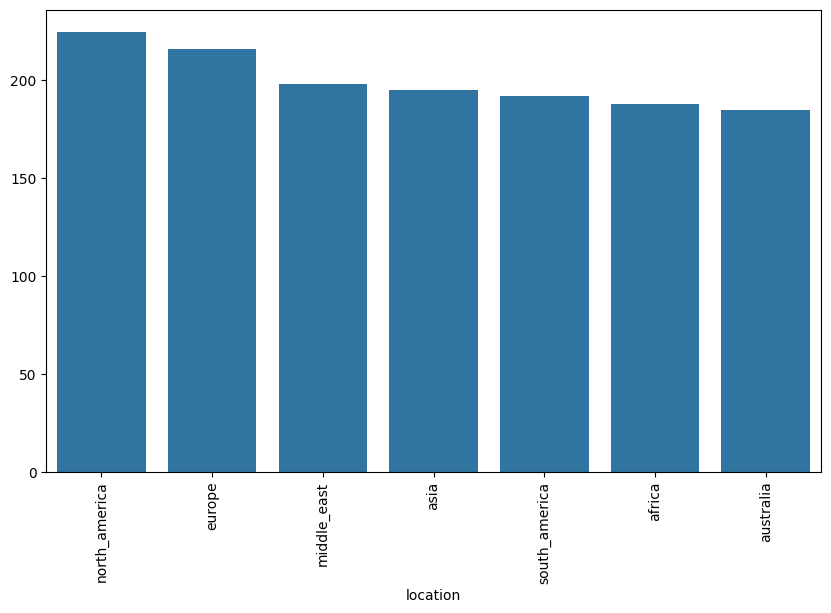

In [149]:
plt.figure(figsize=(10,6))
sns.barplot(x=df.location.value_counts().index, y=df.location.value_counts().values)
plt.xticks(rotation=90)
plt.show()  

In [150]:
df.interaction_count.nunique()

12

In [151]:
df.converted.value_counts()

converted
1    905
0    557
Name: count, dtype: int64

### Data preparation

In [152]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [153]:
cols = ['lead_source', 'industry', 'employment_status', 'location']
df.loc[:, cols] = df[cols].fillna('NA')

In [154]:
df.isnull().sum()

lead_source                   0
industry                      0
number_of_courses_viewed      0
annual_income               181
employment_status             0
location                      0
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [155]:
df['annual_income'].fillna(0.0, inplace = True)

/var/folders/g2/z2xpfp7x5hvgkf6rx1kgrx4w0000gn/T/ipykernel_2911/1679721151.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['annual_income'].fillna(0.0, inplace = True)


In [156]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NA,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NA,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [157]:
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [171]:
X_train, X_temp = train_test_split(df, test_size=0.4, random_state=42)

X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)

In [172]:
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 877
Validation size: 292
Test size: 293


### ROC AUC feature importance

In [188]:
X_train_drop = X_train.select_dtypes(include='number').drop('converted', axis=1) 
y_train_target = X_train['converted']

In [189]:
X_train_drop.head()

,number_of_courses_viewed,annual_income,interaction_count,lead_score
442,1,61705.0,4,0.65
319,1,55199.0,4,0.09
767,1,40841.0,4,0.61
756,1,28242.0,3,0.84
424,0,64775.0,3,0.70


In [190]:
# ROC AUC
auc_scores = {}

for col in X_train_drop.columns:
    try:
        auc = roc_auc_score(y_train_target, X_train_drop[col])
        auc_scores[col] = auc
    except ValueError:
        auc_scores[col] = None  # In case of constant feature

# Sort features by AUC
auc_importance = pd.Series(auc_scores).sort_values(ascending=False)
print(auc_importance)


number_of_courses_viewed    0.767609
interaction_count           0.718899
lead_score                  0.628188
annual_income               0.520471
dtype: float64


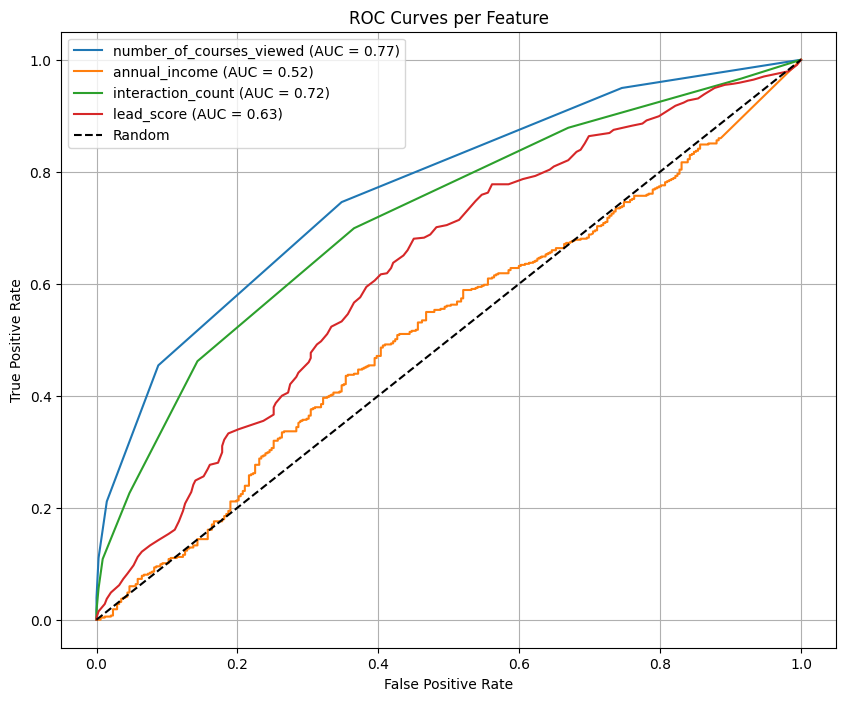

In [199]:
plt.figure(figsize=(10,8))

for col in X_train_drop.columns:
    fpr, tpr, _ = roc_curve(y_train_target, X_train_drop[col])
    auc = auc_scores[col]
    plt.plot(fpr, tpr, label=f'{col} (AUC = {auc:.2f})')

# Random classifier
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Feature')
plt.grid(True)
plt.legend()
plt.show()


In [201]:
print('Answer 1: The numerical feature with the highest ROC AUC score is "number_of_courses_viewed with 0.77".')

Answer 1: The numerical feature with the highest ROC AUC score is "number_of_courses_viewed with 0.77".
